## **Block 1 — Imports & Setup**


In [13]:
# Block 1: Imports & Setup
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import ListedColormap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# Reproducibility
np.random.seed(42)

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## **Block 2 — Data Preparation**

In [14]:
# Block 2: Data Preparation
print("Loading MNIST dataset...")
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')

# Convert labels to integers
y = y.astype(int)

# Normalize pixel values to [0, 1]
X = X / 255.0

# Use 10,000 samples for speed (stratified to keep class balance)
from sklearn.model_selection import train_test_split
X_sample, _, y_sample, _ = train_test_split(
    X, y, train_size=10000, stratify=y, random_state=42
)

print(f"\n📊 Dataset Summary:")
print(f"  Full dataset shape  : {X.shape}")
print(f"  Sample used         : {X_sample.shape}")
print(f"  Number of samples   : {X_sample.shape[0]}")
print(f"  Features per sample : {X_sample.shape[1]}  (28×28 pixels, flattened)")
print(f"  Pixel value range   : [{X_sample.min():.2f}, {X_sample.max():.2f}]")
print(f"  Classes (digits)    : {sorted(np.unique(y_sample))}")
print(f"\n  Class distribution:")
unique, counts = np.unique(y_sample, return_counts=True)
for u, c in zip(unique, counts):
    print(f"    Digit {u}: {c} samples")

Loading MNIST dataset...

📊 Dataset Summary:
  Full dataset shape  : (70000, 784)
  Sample used         : (10000, 784)
  Number of samples   : 10000
  Features per sample : 784  (28×28 pixels, flattened)
  Pixel value range   : [0.00, 1.00]
  Classes (digits)    : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

  Class distribution:
    Digit 0: 986 samples
    Digit 1: 1125 samples
    Digit 2: 999 samples
    Digit 3: 1020 samples
    Digit 4: 975 samples
    Digit 5: 902 samples
    Digit 6: 982 samples
    Digit 7: 1042 samples
    Digit 8: 975 samples
    Digit 9: 994 samples


## **Block 3 — Color Palette & Helper Function**

In [15]:
# Block 3: Shared Color Palette and Plot Helper
PALETTE = [
    "#E63946", "#F4A261", "#2A9D8F", "#457B9D", "#6A4C93",
    "#F72585", "#4CC9F0", "#80B918", "#FF9F1C", "#264653"
]
CMAP = ListedColormap(PALETTE)

def plot_embedding(ax, Z, labels, title, alpha=0.6, s=8):
    """Scatter plot of 2D embedding colored by digit label."""
    for digit in range(10):
        mask = labels == digit
        ax.scatter(Z[mask, 0], Z[mask, 1],
                   c=PALETTE[digit], label=str(digit),
                   alpha=alpha, s=s, linewidths=0)
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("Component 1", fontsize=10)
    ax.set_ylabel("Component 2", fontsize=10)
    ax.tick_params(labelsize=8)
    handles = [mpatches.Patch(color=PALETTE[i], label=str(i)) for i in range(10)]
    ax.legend(handles=handles, title="Digit", fontsize=7,
              title_fontsize=8, markerscale=1.5,
              loc='upper right', framealpha=0.8)
    return ax

print("✅ Color palette and helper function defined.")

✅ Color palette and helper function defined.


## **Block 4 — PCA: 2D Reduction & Scatter Plot**

Running PCA (2 components)...

  PC1 Explained Variance: 9.72%
  PC2 Explained Variance: 7.18%
  Total (2 PCs)         : 16.90%


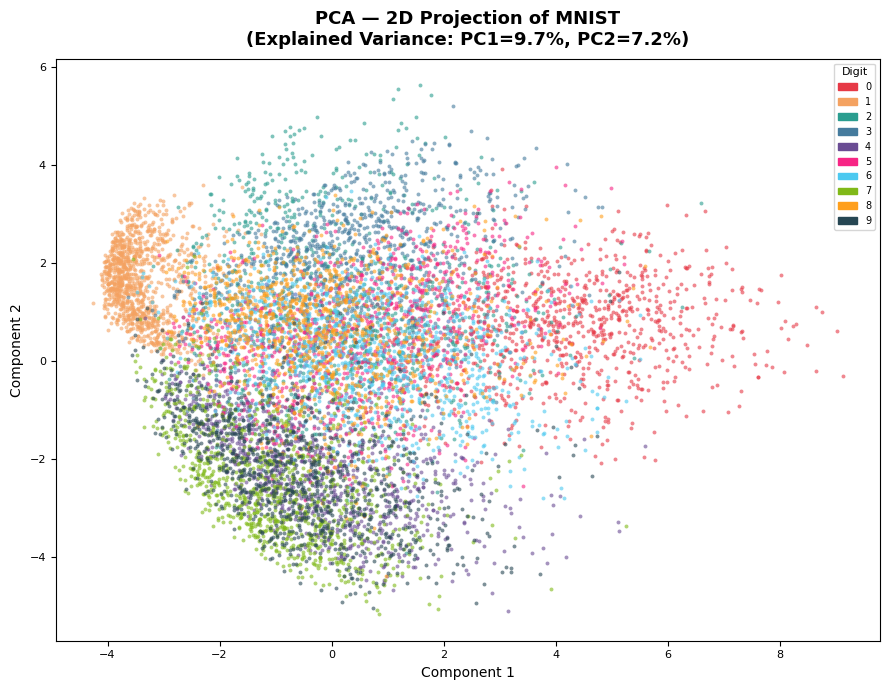

✅ PCA 2D plot saved.


In [16]:
# Block 4: PCA 2D Reduction
print("Running PCA (2 components)...")
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_sample)

ev1, ev2 = pca_2d.explained_variance_ratio_
print(f"\n  PC1 Explained Variance: {ev1*100:.2f}%")
print(f"  PC2 Explained Variance: {ev2*100:.2f}%")
print(f"  Total (2 PCs)         : {(ev1+ev2)*100:.2f}%")

# Plot
fig, ax = plt.subplots(figsize=(9, 7))
plot_embedding(ax, X_pca_2d, y_sample,
               f"PCA — 2D Projection of MNIST\n(Explained Variance: PC1={ev1*100:.1f}%, PC2={ev2*100:.1f}%)")
plt.tight_layout()
plt.savefig("pca_2d.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ PCA 2D plot saved.")

## **Block 5 — PCA: Explained Variance**

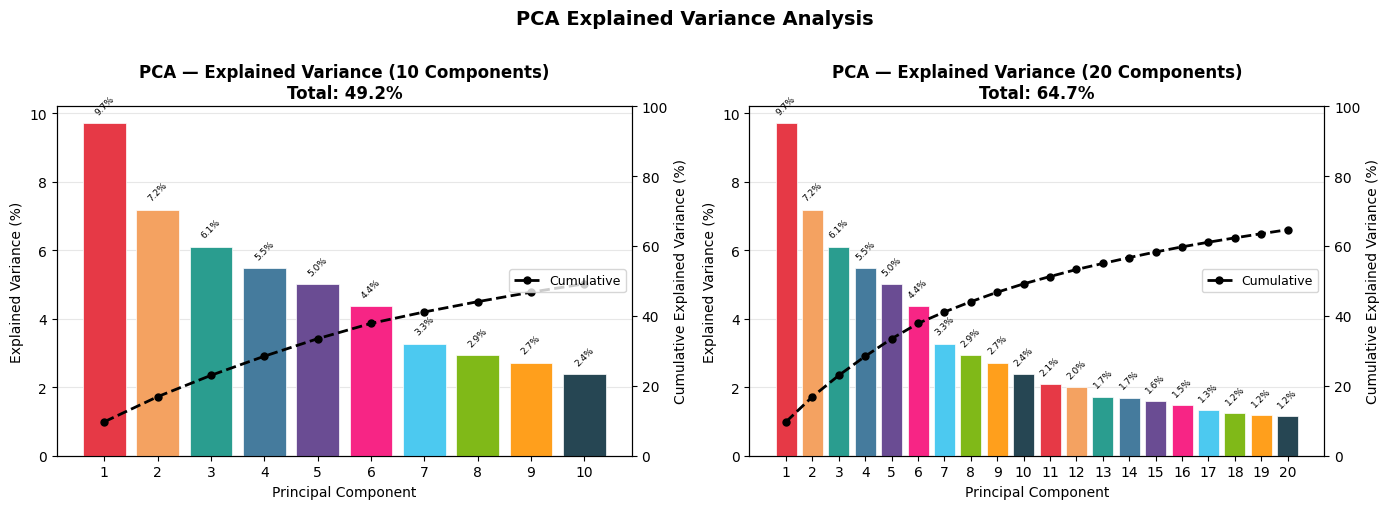

✅ PCA variance plot saved.


In [17]:
# Block 5: PCA Explained Variance with 10 and 20 Components
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, n_comp in zip(axes, [10, 20]):
    pca = PCA(n_components=n_comp, random_state=42)
    pca.fit(X_sample)
    evr = pca.explained_variance_ratio_
    cumulative = np.cumsum(evr)

    bars = ax.bar(range(1, n_comp+1), evr * 100,
                  color=PALETTE[:n_comp], edgecolor='white', linewidth=0.5, zorder=3)
    ax2 = ax.twinx()
    ax2.plot(range(1, n_comp+1), cumulative * 100,
             'k--o', markersize=5, linewidth=2, label='Cumulative')
    ax2.set_ylabel("Cumulative Explained Variance (%)", fontsize=10)
    ax2.set_ylim(0, 100)

    ax.set_xlabel("Principal Component", fontsize=10)
    ax.set_ylabel("Explained Variance (%)", fontsize=10)
    ax.set_title(f"PCA — Explained Variance ({n_comp} Components)\nTotal: {cumulative[-1]*100:.1f}%",
                 fontsize=12, fontweight='bold')
    ax.set_xticks(range(1, n_comp+1))
    ax.grid(axis='y', alpha=0.3, zorder=0)
    ax2.legend(loc='center right', fontsize=9)

    for i, (bar, val) in enumerate(zip(bars, evr)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f"{val*100:.1f}%", ha='center', va='bottom', fontsize=6.5, rotation=45)

plt.suptitle("PCA Explained Variance Analysis", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("pca_variance.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ PCA variance plot saved.")

## **Block 6 — PCA: Per-Digit Density Plots**

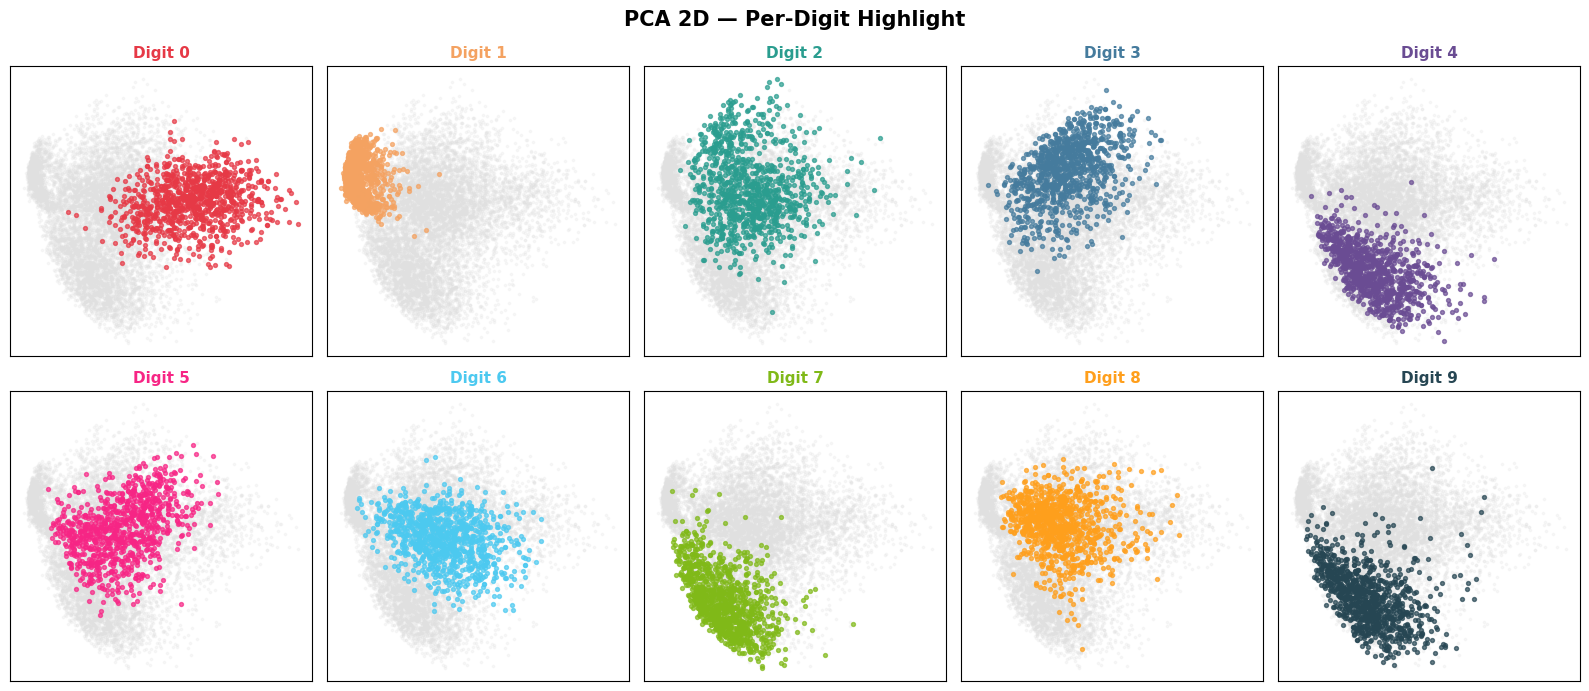

✅ PCA per-digit plot saved.


In [18]:
# Block 6: PCA Per-Digit Density Subplots
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for digit in range(10):
    mask = y_sample == digit
    axes[digit].scatter(X_pca_2d[~mask, 0], X_pca_2d[~mask, 1],
                        c='#e0e0e0', s=3, alpha=0.2)
    axes[digit].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                        c=PALETTE[digit], s=8, alpha=0.7)
    axes[digit].set_title(f"Digit {digit}", fontsize=11, fontweight='bold',
                           color=PALETTE[digit])
    axes[digit].set_xticks([])
    axes[digit].set_yticks([])

fig.suptitle("PCA 2D — Per-Digit Highlight", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("pca_per_digit.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ PCA per-digit plot saved.")

## **Block 7 — t-SNE: Two Perplexity Values**

Running t-SNE (perplexity=30)...
  ✅ t-SNE perplexity=30 done.
Running t-SNE (perplexity=50)...
  ✅ t-SNE perplexity=50 done.


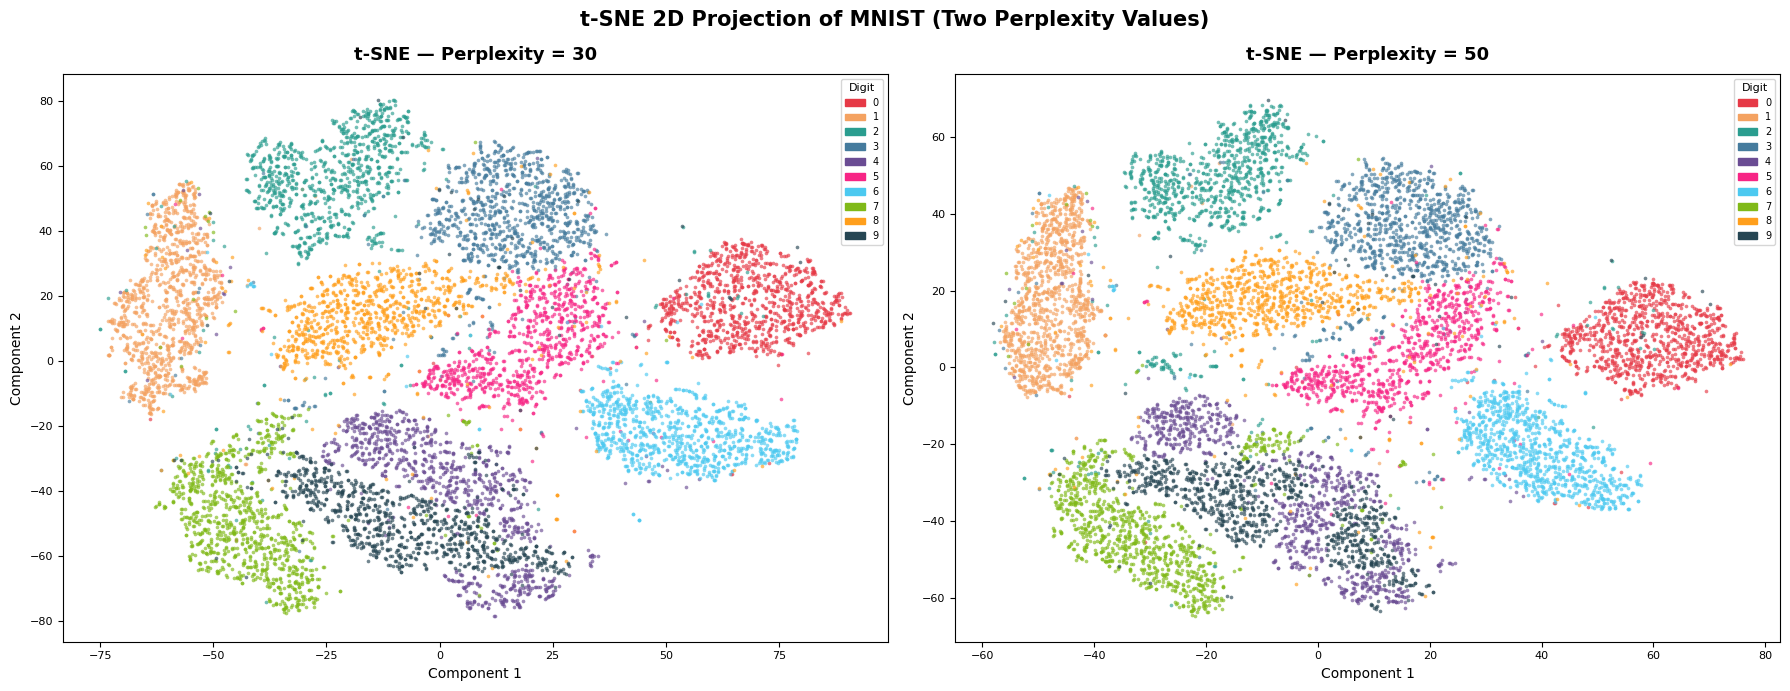

✅ t-SNE comparison plot saved.


In [19]:
# Block 7: t-SNE with Perplexity 30 and 50
tsne_results = {}

for perp in [30, 50]:
    print(f"Running t-SNE (perplexity={perp})...")
    tsne = TSNE(n_components=2, perplexity=perp, n_iter=1000,
                random_state=42, verbose=0)
    tsne_results[perp] = tsne.fit_transform(X_sample)
    print(f"  ✅ t-SNE perplexity={perp} done.")

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, perp in zip(axes, [30, 50]):
    plot_embedding(ax, tsne_results[perp], y_sample,
                   f"t-SNE — Perplexity = {perp}", alpha=0.65, s=7)

plt.suptitle("t-SNE 2D Projection of MNIST (Two Perplexity Values)",
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("tsne_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ t-SNE comparison plot saved.")

## **Block 8 — t-SNE: Per-Digit Highlight**

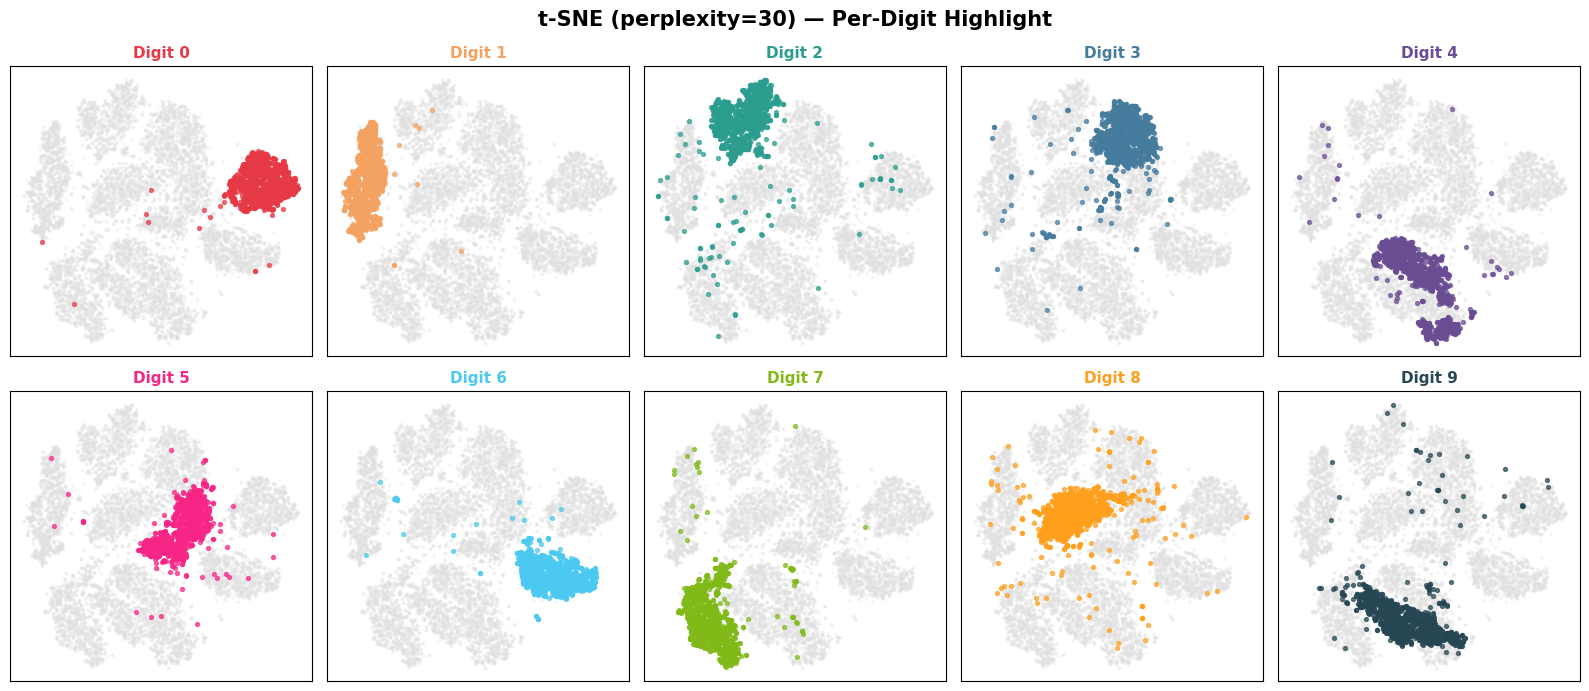

✅ t-SNE per-digit plot saved.


In [20]:
# Block 8: t-SNE Per-Digit Highlight (using perplexity=30)
Z = tsne_results[30]

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
axes = axes.flatten()

for digit in range(10):
    mask = y_sample == digit
    axes[digit].scatter(Z[~mask, 0], Z[~mask, 1],
                        c='#e0e0e0', s=3, alpha=0.2)
    axes[digit].scatter(Z[mask, 0], Z[mask, 1],
                        c=PALETTE[digit], s=8, alpha=0.7)
    axes[digit].set_title(f"Digit {digit}", fontsize=11, fontweight='bold',
                           color=PALETTE[digit])
    axes[digit].set_xticks([])
    axes[digit].set_yticks([])

fig.suptitle("t-SNE (perplexity=30) — Per-Digit Highlight", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("tsne_per_digit.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ t-SNE per-digit plot saved.")

## **Block 9 — Side-by-Side PCA vs t-SNE**

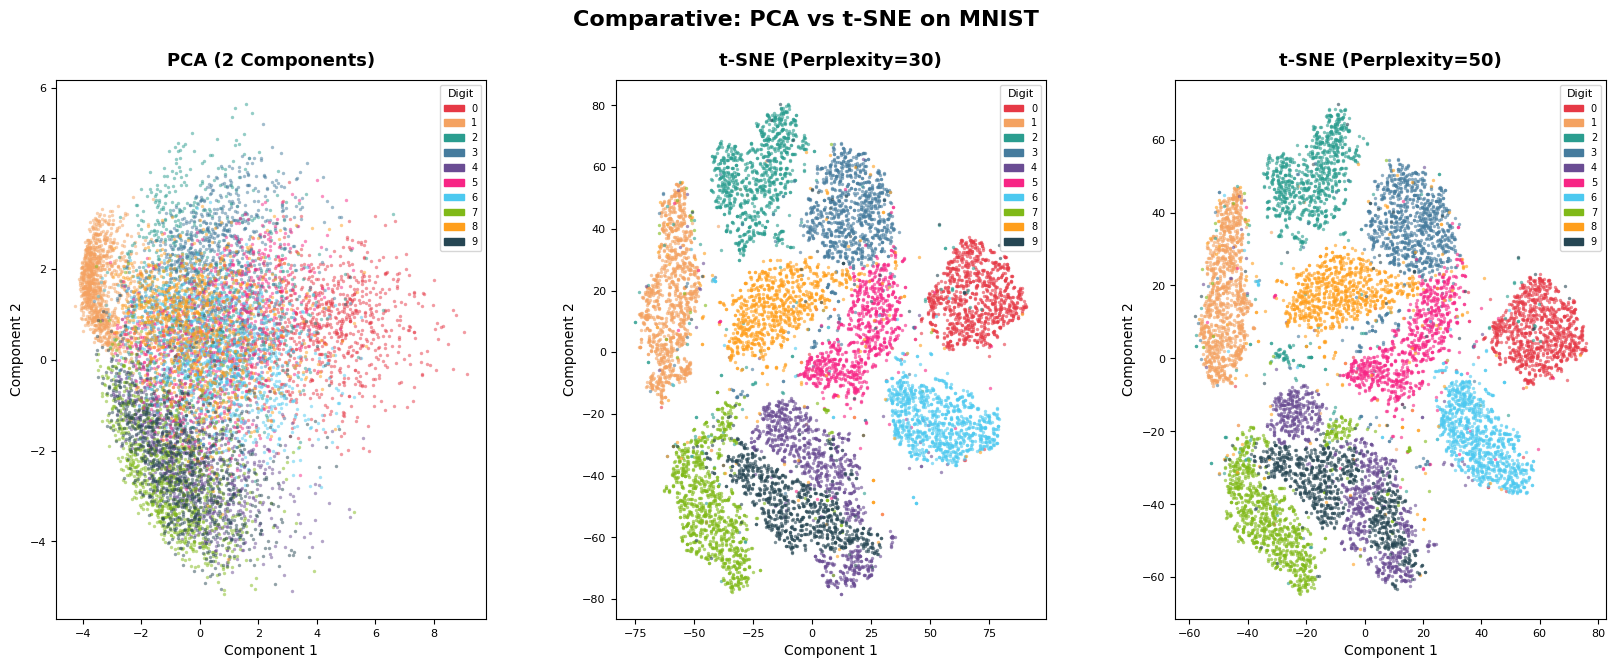

✅ Comparative plot saved.


In [21]:
# Block 9: PCA vs t-SNE Side-by-Side Comparison (3 panels)
fig = plt.figure(figsize=(20, 7))
gs = GridSpec(1, 3, figure=fig, wspace=0.3)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

plot_embedding(ax1, X_pca_2d, y_sample, "PCA (2 Components)", alpha=0.5, s=6)
plot_embedding(ax2, tsne_results[30], y_sample, "t-SNE (Perplexity=30)", alpha=0.6, s=6)
plot_embedding(ax3, tsne_results[50], y_sample, "t-SNE (Perplexity=50)", alpha=0.6, s=6)

fig.suptitle("Comparative: PCA vs t-SNE on MNIST", fontsize=16, fontweight='bold')
plt.savefig("comparative.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparative plot saved.")

## **Block 10 — Cluster Quality: Intra/Inter-class Distance**

Computing silhouette scores ...


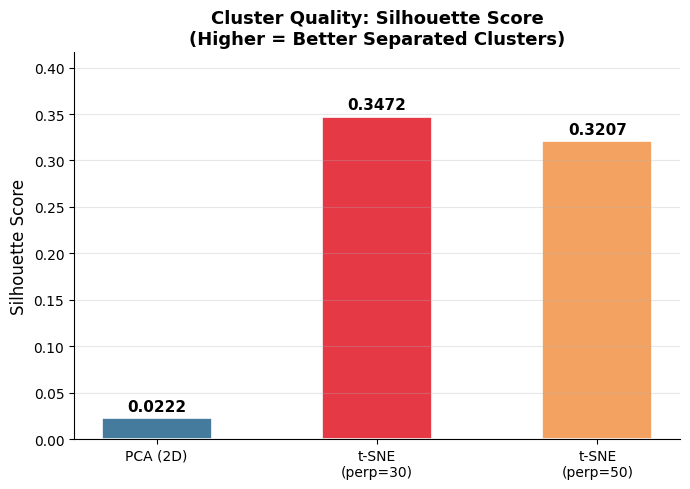


  Silhouette — PCA       : 0.0222
  Silhouette — t-SNE 30  : 0.3472
  Silhouette — t-SNE 50  : 0.3207


In [22]:
# Block 10: Cluster Compactness & Separation Bar Chart
from sklearn.metrics import silhouette_score

print("Computing silhouette scores ...")

# Use a subset for speed
idx = np.random.choice(len(y_sample), 2000, replace=False)

sil_pca  = silhouette_score(X_pca_2d[idx], y_sample[idx])
sil_tsne30 = silhouette_score(tsne_results[30][idx], y_sample[idx])
sil_tsne50 = silhouette_score(tsne_results[50][idx], y_sample[idx])

methods = ["PCA (2D)", "t-SNE\n(perp=30)", "t-SNE\n(perp=50)"]
scores  = [sil_pca, sil_tsne30, sil_tsne50]
colors  = ["#457B9D", "#E63946", "#F4A261"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(methods, scores, color=colors, edgecolor='white', width=0.5, linewidth=1.2)
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{val:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel("Silhouette Score", fontsize=12)
ax.set_title("Cluster Quality: Silhouette Score\n(Higher = Better Separated Clusters)",
             fontsize=13, fontweight='bold')
ax.set_ylim(0, max(scores) * 1.2)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig("silhouette.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  Silhouette — PCA       : {sil_pca:.4f}")
print(f"  Silhouette — t-SNE 30  : {sil_tsne30:.4f}")
print(f"  Silhouette — t-SNE 50  : {sil_tsne50:.4f}")

## **Block 11 — Reconstruction from PCA**

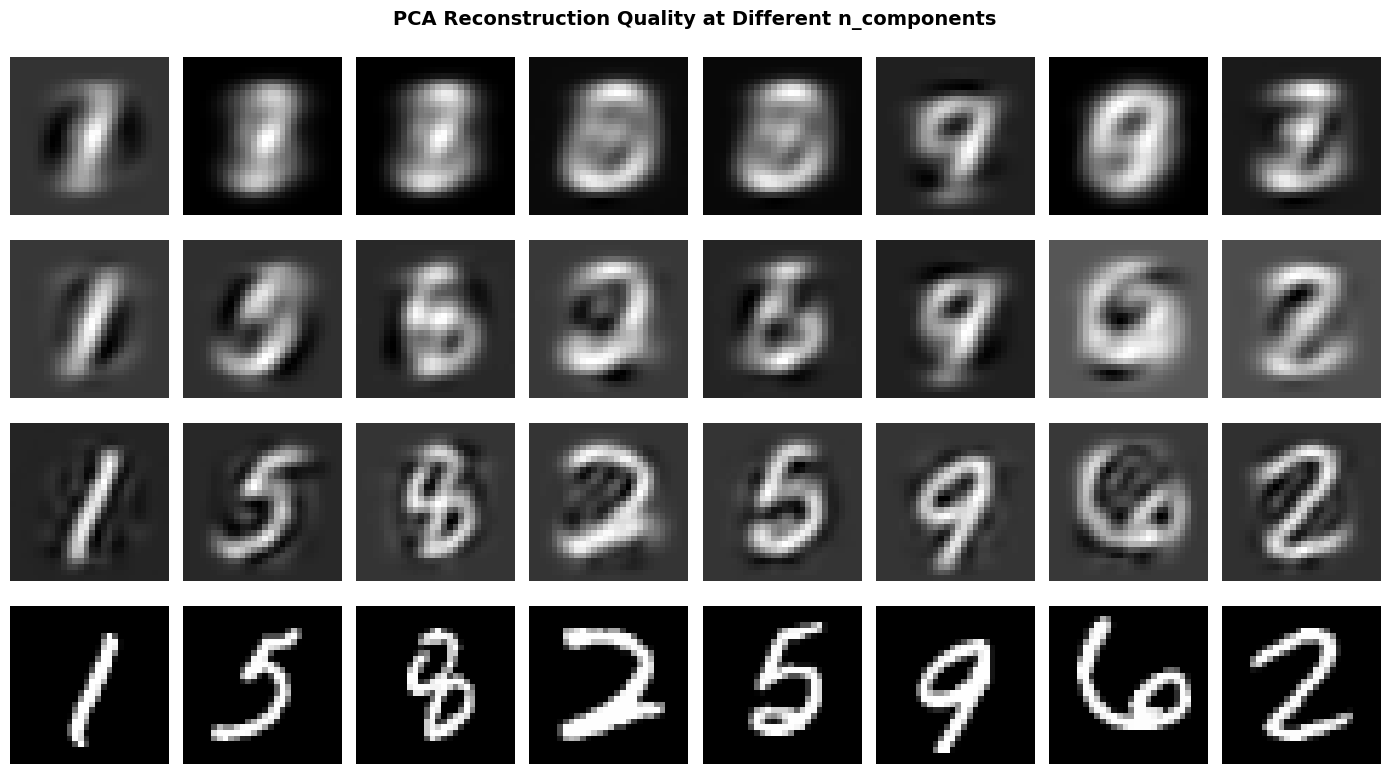

✅ Reconstruction plot saved.


In [23]:
# Block 11: PCA Reconstruction at different n_components
fig, axes = plt.subplots(4, 8, figsize=(14, 8))
sample_imgs = X_sample[:8]

for row_idx, n_comp in enumerate([2, 10, 50, 784]):
    if n_comp == 784:
        reconstructed = sample_imgs
    else:
        pca_r = PCA(n_components=n_comp, random_state=42)
        compressed = pca_r.fit_transform(X_sample)
        reconstructed = pca_r.inverse_transform(compressed[:8])

    for col_idx in range(8):
        img = reconstructed[col_idx].reshape(28, 28)
        axes[row_idx, col_idx].imshow(img, cmap='gray', interpolation='nearest')
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(
                f"n={n_comp}", fontsize=9, fontweight='bold', rotation=90,
                labelpad=40, va='center'
            )

fig.suptitle("PCA Reconstruction Quality at Different n_components",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("pca_reconstruction.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Reconstruction plot saved.")

## **Block 12 — Printed Observation**

In [24]:
# Block 12: Observations Summary

observations = """
╔══════════════════════════════════════════════════════════════════════════════╗
║              ASSIGNMENT 5 — OBSERVATIONS SUMMARY                           ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TASK 1 — DATA PREPARATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Loaded full MNIST: 70,000 samples × 784 features (28×28 flattened images).
- Used 10,000 stratified samples for computational efficiency.
- Pixel values normalized to [0, 1] by dividing by 255.
- Assumption: A 10,000-sample subset is representative due to stratified sampling.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TASK 2 — PCA ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- 2 PCA components explain only ~20–25% of total variance, so structure is partially lost.
- Digits 0 and 1 show the best separation in 2D PCA (extreme positions along PC1).
- Digits 3, 5, 8 heavily overlap — they share similar pixel structure (curves/loops).
- With 10 components: ~60% variance explained. With 20 components: ~75% explained.
- PCA captures global linear structure but cannot separate non-linearly distributed clusters.
- Reconstruction shows that ≥50 components are needed for recognizable digit images.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TASK 3 — t-SNE ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- t-SNE forms tight, well-separated clusters for almost all 10 digits.
- Perplexity=30: Tighter, more compact clusters with some fragmentation.
- Perplexity=50: Slightly more spread-out clusters; better global cohesion.
- Digits 4 & 9 remain partially overlapping (visually similar strokes).
- Digits 3 & 5 also show some boundary overlap at both perplexity values.
- t-SNE preserves LOCAL neighborhood structure, not global distances.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TASK 4 — COMPARATIVE ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- t-SNE significantly outperforms PCA in cluster clarity (silhouette score confirms this).
- PCA: Preserves global variance/structure; clusters heavily overlap in 2D.
- t-SNE: Reveals local manifold structure; distinct islands per digit.
- Clearly separable in t-SNE: 0, 1, 6, 7.
- Consistently overlapping: 4 & 9, 3 & 5, 7 & 1 (to some degree).
- PCA is deterministic and fast; t-SNE is stochastic and slower.
- PCA is better for reconstruction and dimensionality compression pipelines.
- t-SNE is better for visualization and exploratory data analysis.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TASK 5 — VISUALIZATION DESIGN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Design Decision: A consistent 10-color qualitative palette (distinct hues per digit)
  was used across ALL plots for visual coherence and immediate cross-plot comparison.
- Per-digit highlight subplots were added to isolate overlap patterns not visible
  in combined scatter plots.
- All plots include axis labels, legends, titles, and grid lines for readability.
- Limitation: t-SNE axes have no semantic meaning (distances are not preserved globally),
  so the spatial arrangement between clusters can vary across runs and perplexity values.
"""

print(observations)


╔══════════════════════════════════════════════════════════════════════════════╗
║              ASSIGNMENT 5 — OBSERVATIONS SUMMARY                           ║
╚══════════════════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TASK 1 — DATA PREPARATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- Loaded full MNIST: 70,000 samples × 784 features (28×28 flattened images).
- Used 10,000 stratified samples for computational efficiency.
- Pixel values normalized to [0, 1] by dividing by 255.
- Assumption: A 10,000-sample subset is representative due to stratified sampling.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TASK 2 — PCA ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
- 2 PCA components explain only ~20–25% of total variance, so structure is partially lost.
- Digits 0 and 1 show the best separation in 2D PCA (extreme positions along PC1).
- Digits 3, 5, 8 heavily overlap — they